# **Evaluation Results**

In [1]:
import json

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
with open("./results/planner_metrics.json", "r") as file:
    loaded_metrics = json.load(file)

planner_metrics = {}

for key, metrics in loaded_metrics.items():
    planner_name, scenario_index = key.split("|")
    scenario_index = int(scenario_index)
    planner_metrics[(planner_name, scenario_index)] = metrics

In [3]:
with open("./results/average_planner_metrics.json", "r") as file:
    loaded_average_metrics = json.load(file)

average_metrics = {}

for key, metrics in loaded_average_metrics.items():
    planner_name = key
    average_metrics[planner_name] = metrics

In [4]:
with open("./results/best_fitness_scores.json", "r") as file:
    loaded_fitness_scores = json.load(file)

best_fitness_scores = {}

for key, score in loaded_fitness_scores.items():
    planner_name, scenario_index = key.split("|")
    scenario_index = int(scenario_index)
    best_fitness_scores[(planner_name, scenario_index)] = score

## Evaluation Metrics

In [5]:
sns.set_theme("notebook")
colours = sns.color_palette("husl", len(planner_metrics))

In [6]:
metrics_to_plot = [
    ("ingredient_utilisation_score_mean", "Ingredient Utilisation"),
    ("expiry_weighted_utilisation_score_mean", "Expiry-Weighted Utilisation"),
    ("food_waste_score_mean", "Food Waste"),
    ("dietary_constraint_compliance_mean", "Dietary Constraint Compliance"),
    ("nutritional_target_score_mean", "Nutritional Target Compliance"),
    ("budget_efficiency_mean", "Budget Efficiency"),
    ("pantry_coverage_score_mean", "Pantry Coverage"),
    ("variety_score_mean", "Variety"),
    ("runtime_seconds_mean", "Runtime (seconds)"),
]

In [7]:
scenario_names = [
    "Scenario 1: Standard",
    "Scenario 2: Low Budget",
    "Scenario 3: Overcrowded Pantry",
    "Scenario 4: Dietary Restrictions (Vegan + Gluten-Free)",
    "Scenario 5: Dietary Restrictions (Lactose-Free + Vegetarian)",
    "Scenario 6: High Nutritional Targets",
]

In [8]:
def plot_metrics(planner_metrics: dict[str, dict[str, float]], title: str, filename: str) -> None:
    """
    Plots the specified metrics for each meal planner and scenario as horizontal bar charts

    :param planner_metrics: mapping of (meal_planner_name, scenario_index) to metric values
    :type planner_metrics: dict[str, dict[str, float]]
    :param title: the title for the overall plot
    :type title: str
    :param filename: the filename to save the plot as (without extension)
    :type filename: str
    """

    fig, axes = plt.subplots(5, 2, figsize=(20, 12), constrained_layout=True)

    for ax, (metric_key, metric_title) in zip(axes.flat, metrics_to_plot):
        for i, (planner, metrics) in enumerate(planner_metrics.items()):
            ax.barh(i, metrics[metric_key], color=colours[i], label=planner)
            ax.text(metrics[metric_key] + 0.01, i, f"{metrics[metric_key]:.2f}", color="black", va="center")

        ax.set_yticks(range(len(planner_metrics)))
        ax.set_yticklabels(planner_metrics.keys())
        ax.set_title(metric_title, fontweight="bold")

    # hide any unused subplots
    for j in range(len(metrics_to_plot), len(axes.flat)):
        axes.flat[j].axis("off")

    fig.suptitle(title, fontsize=16, fontweight="bold")
    plt.savefig(f"./figures/{filename}.png", dpi = 900)
    plt.show()

### *Scenario 1*

In [9]:
scenario_1_metrics = {planner: metrics for (planner, scenario), metrics in planner_metrics.items() if scenario == 1}

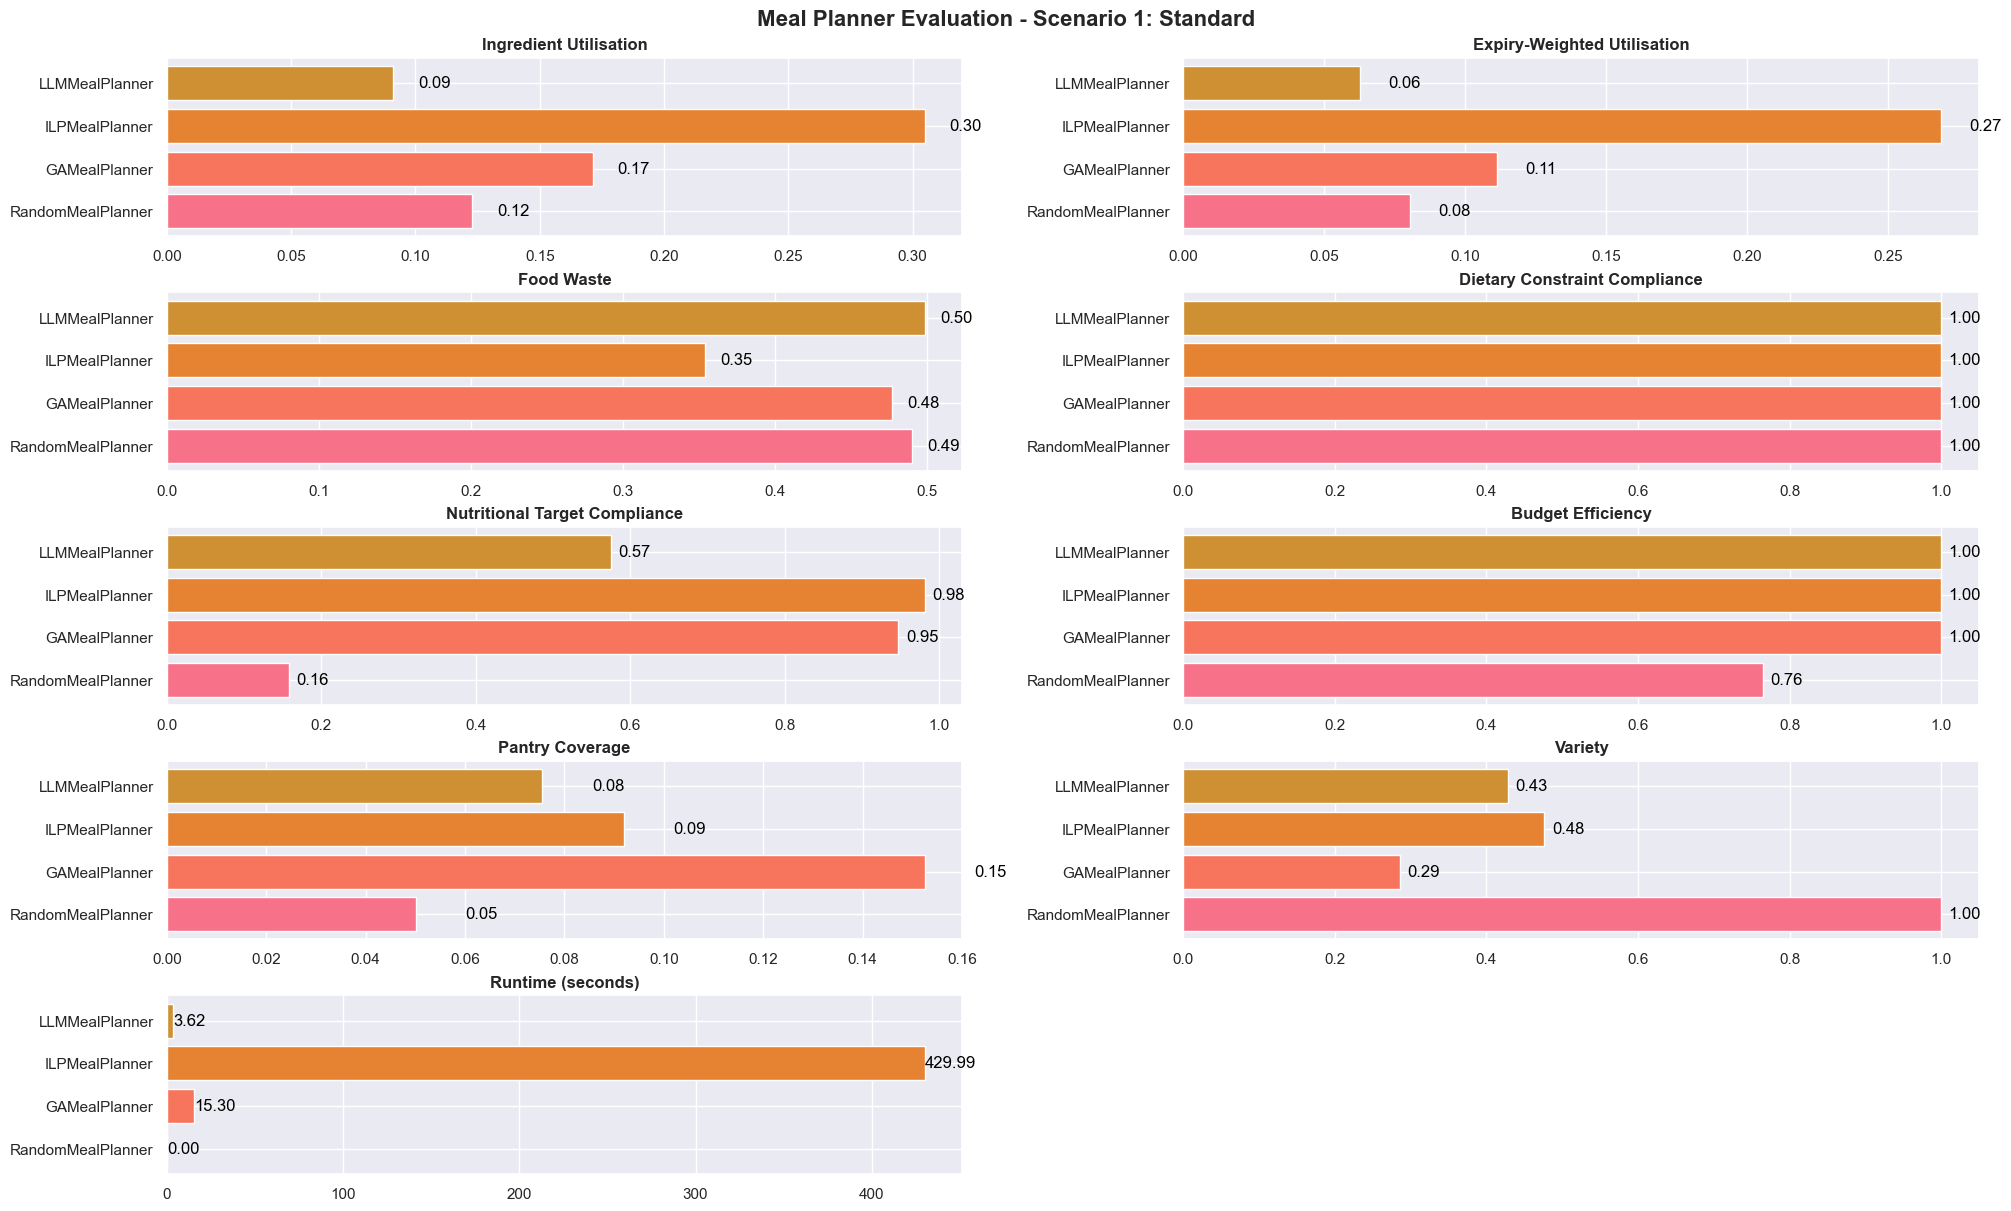

In [10]:
plot_metrics(scenario_1_metrics, f"Meal Planner Evaluation - {scenario_names[0]}", filename = "scenario_1_metrics")

In [11]:
print(
    f"Fitness scores for GA and ILP Meal Planners in {scenario_names[0]} = {best_fitness_scores[('GAMealPlanner', 1)]:.4} (GA), {best_fitness_scores[('ILPMealPlanner', 1)]:.4} (ILP)"
)

Fitness scores for GA and ILP Meal Planners in Scenario 1: Standard = -0.2004 (GA), -0.1636 (ILP)


### *Scenario 2*

In [12]:
scenario_2_metrics = {planner: metrics for (planner, scenario), metrics in planner_metrics.items() if scenario == 2}

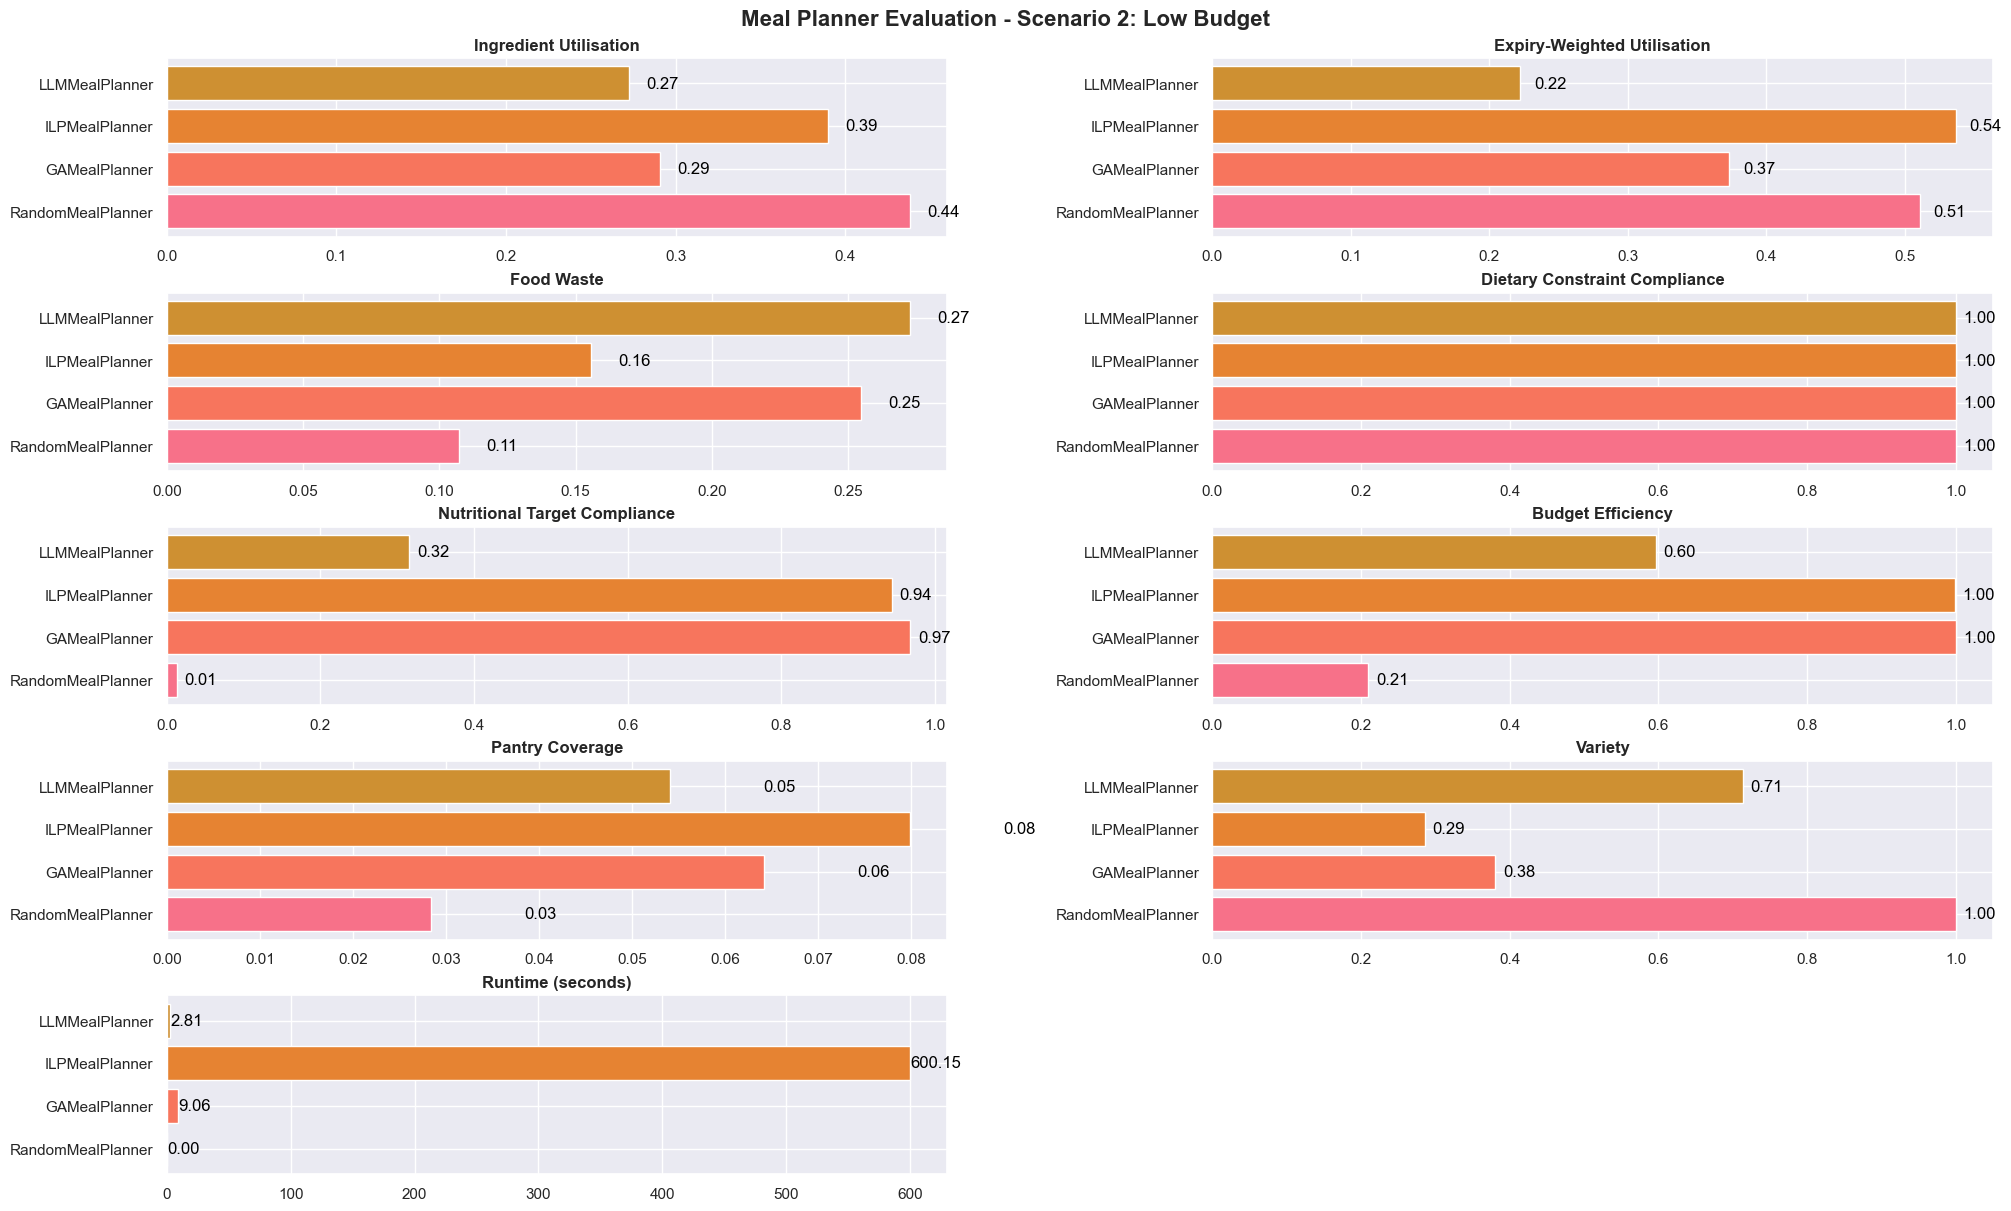

In [13]:
plot_metrics(scenario_2_metrics, f"Meal Planner Evaluation - {scenario_names[1]}", filename = "scenario_2_metrics")

In [14]:
print(
    f"Fitness scores for GA and ILP Meal Planners in {scenario_names[1]} = {best_fitness_scores[('GAMealPlanner', 2)]:.4} (GA), {best_fitness_scores[('ILPMealPlanner', 2)]:.4} (ILP)"
)

Fitness scores for GA and ILP Meal Planners in Scenario 2: Low Budget = -0.07965 (GA), -0.02142 (ILP)


### *Scenario 3*

In [15]:
scenario_3_metrics = {planner: metrics for (planner, scenario), metrics in planner_metrics.items() if scenario == 3}

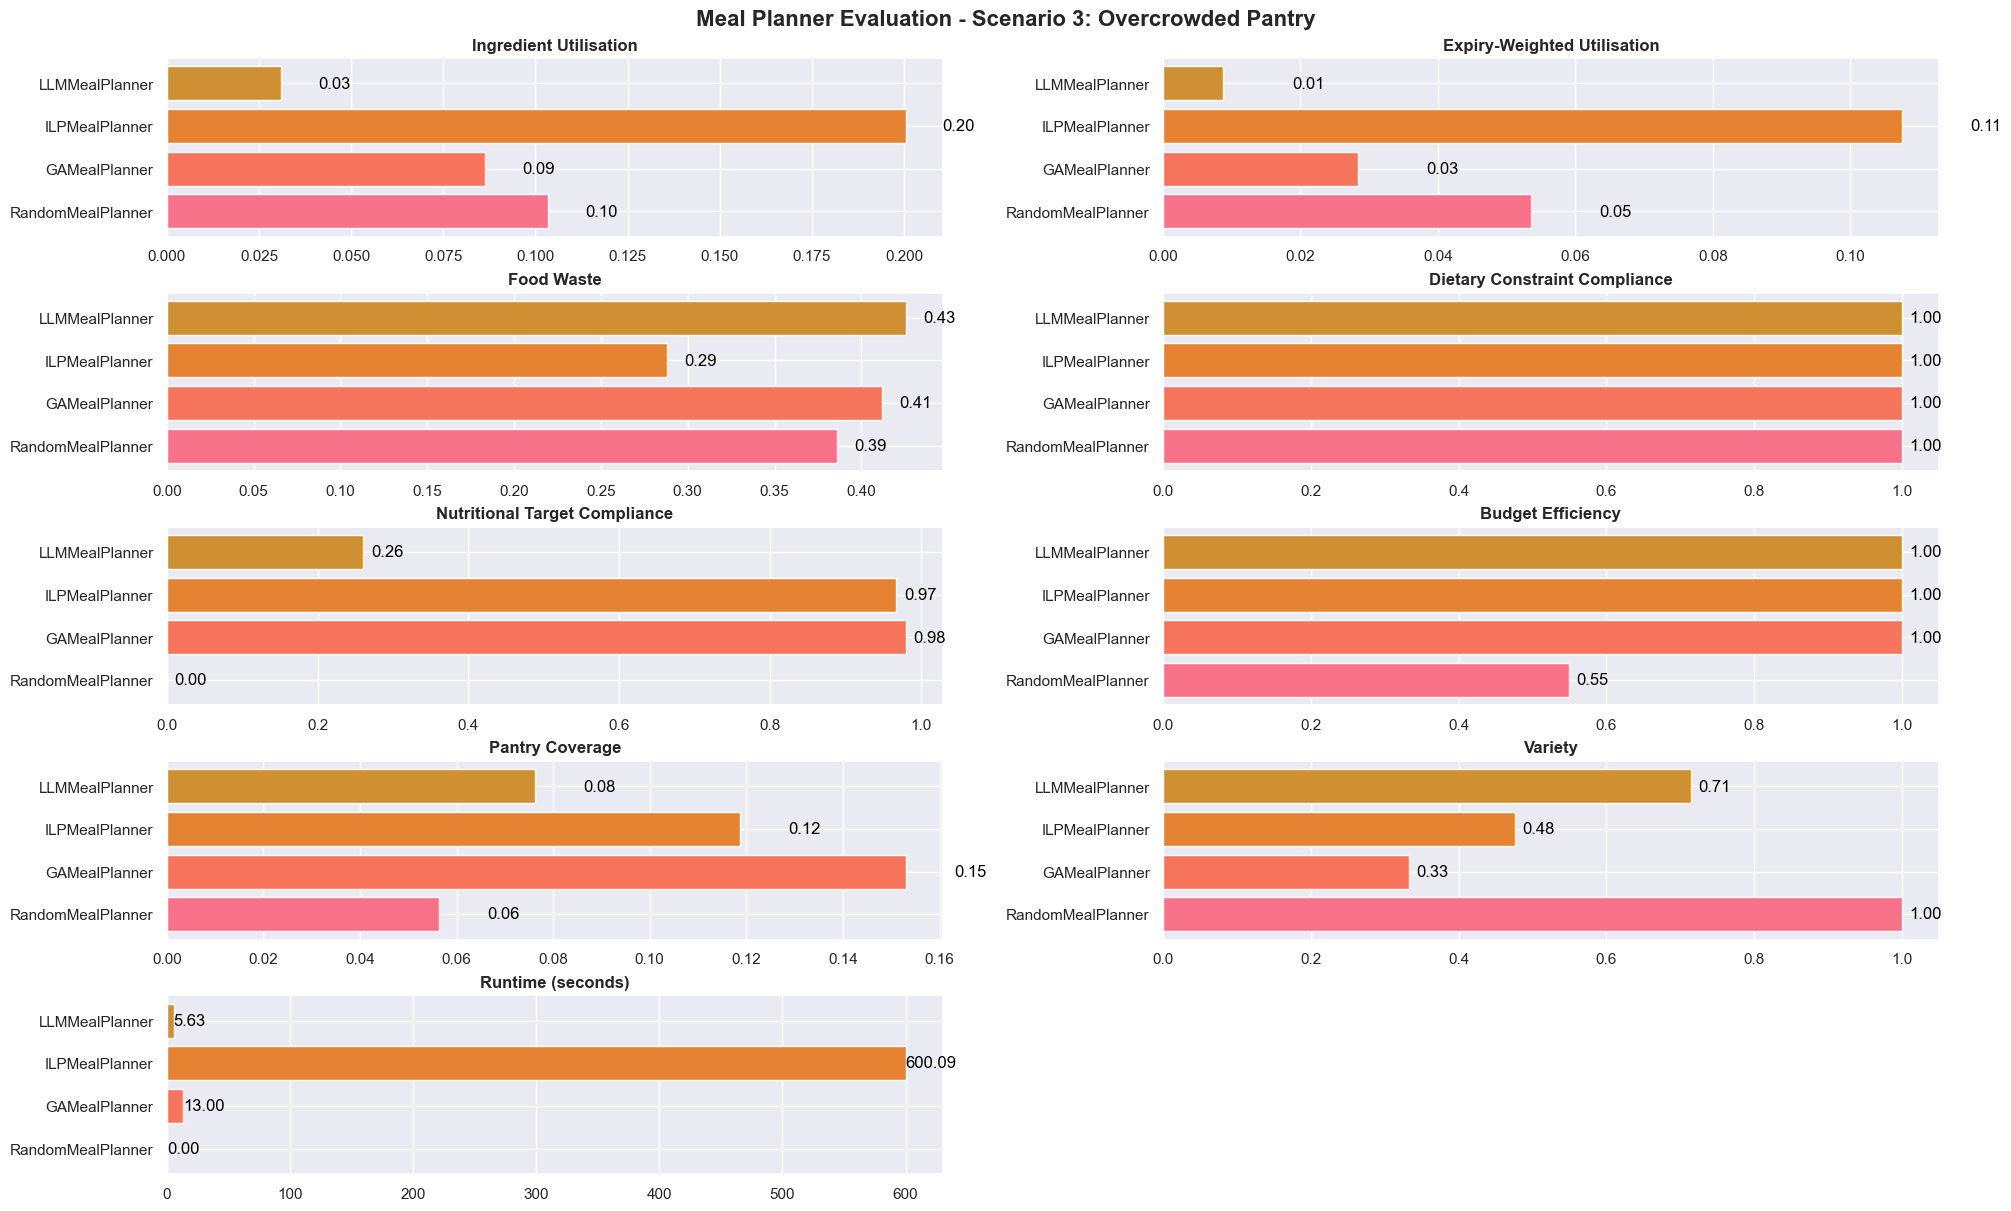

In [16]:
plot_metrics(scenario_3_metrics, f"Meal Planner Evaluation - {scenario_names[2]}", filename = "scenario_3_metrics")

In [17]:
print(
    f"Fitness scores for GA and ILP Meal Planners in {scenario_names[2]} = {best_fitness_scores[('GAMealPlanner', 3)]:.4} (GA), {best_fitness_scores[('ILPMealPlanner', 3)]:.4} (ILP)"
)

Fitness scores for GA and ILP Meal Planners in Scenario 3: Overcrowded Pantry = -0.2149 (GA), -0.2154 (ILP)


### *Scenario 4*

In [18]:
scenario_4_metrics = {planner: metrics for (planner, scenario), metrics in planner_metrics.items() if scenario == 4}

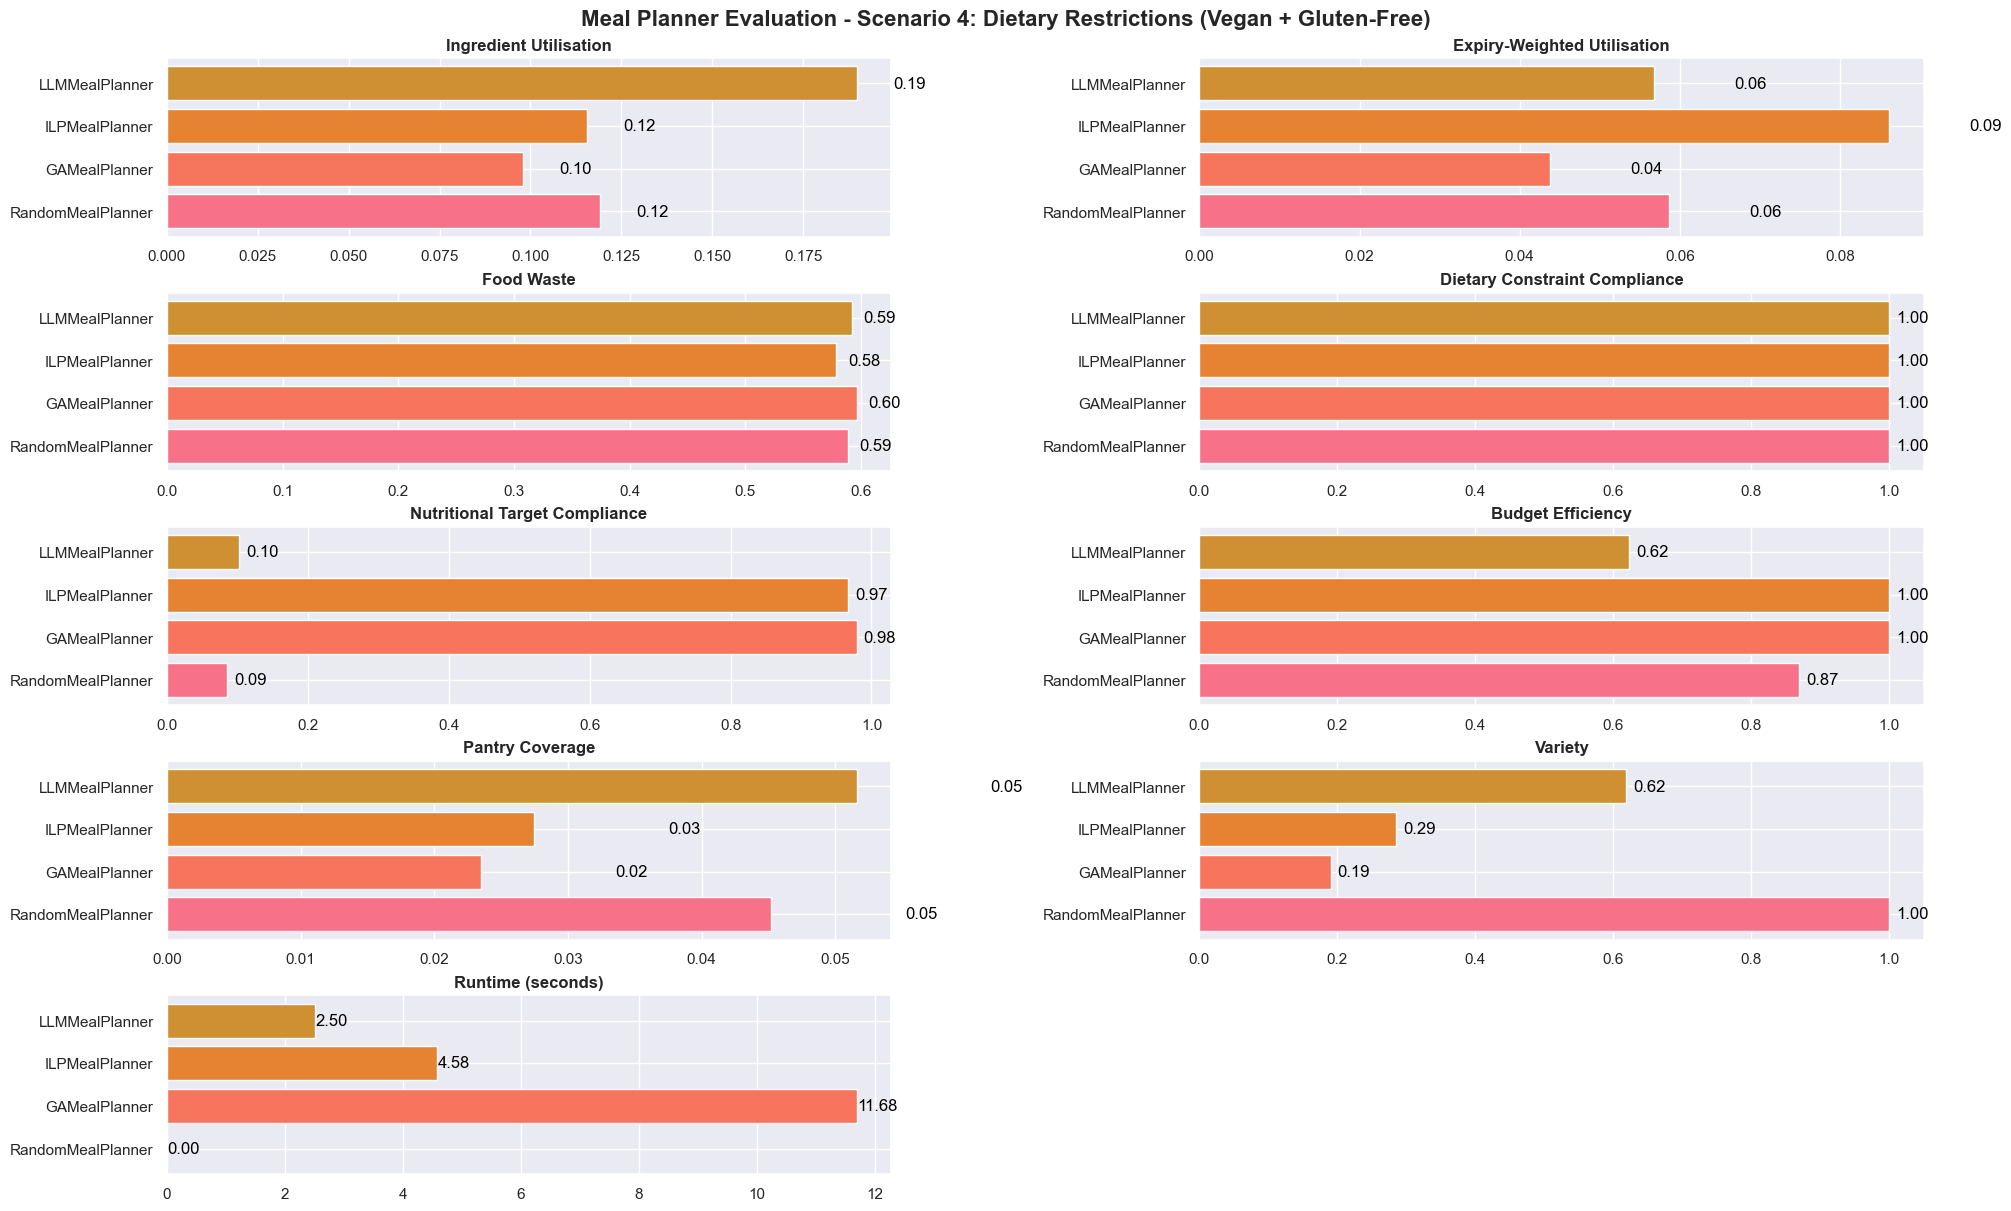

In [19]:
plot_metrics(scenario_4_metrics, f"Meal Planner Evaluation - {scenario_names[3]}", filename = "scenario_4_metrics")

In [20]:
print(
    f"Fitness scores for GA and ILP Meal Planners in {scenario_names[3]} = {best_fitness_scores[('GAMealPlanner', 4)]:.4} (GA), {best_fitness_scores[('ILPMealPlanner', 4)]:.4} (ILP)"
)

Fitness scores for GA and ILP Meal Planners in Scenario 4: Dietary Restrictions (Vegan + Gluten-Free) = -0.354 (GA), -0.3472 (ILP)


### *Scenario 5*

In [21]:
scenario_5_metrics = {planner: metrics for (planner, scenario), metrics in planner_metrics.items() if scenario == 5}

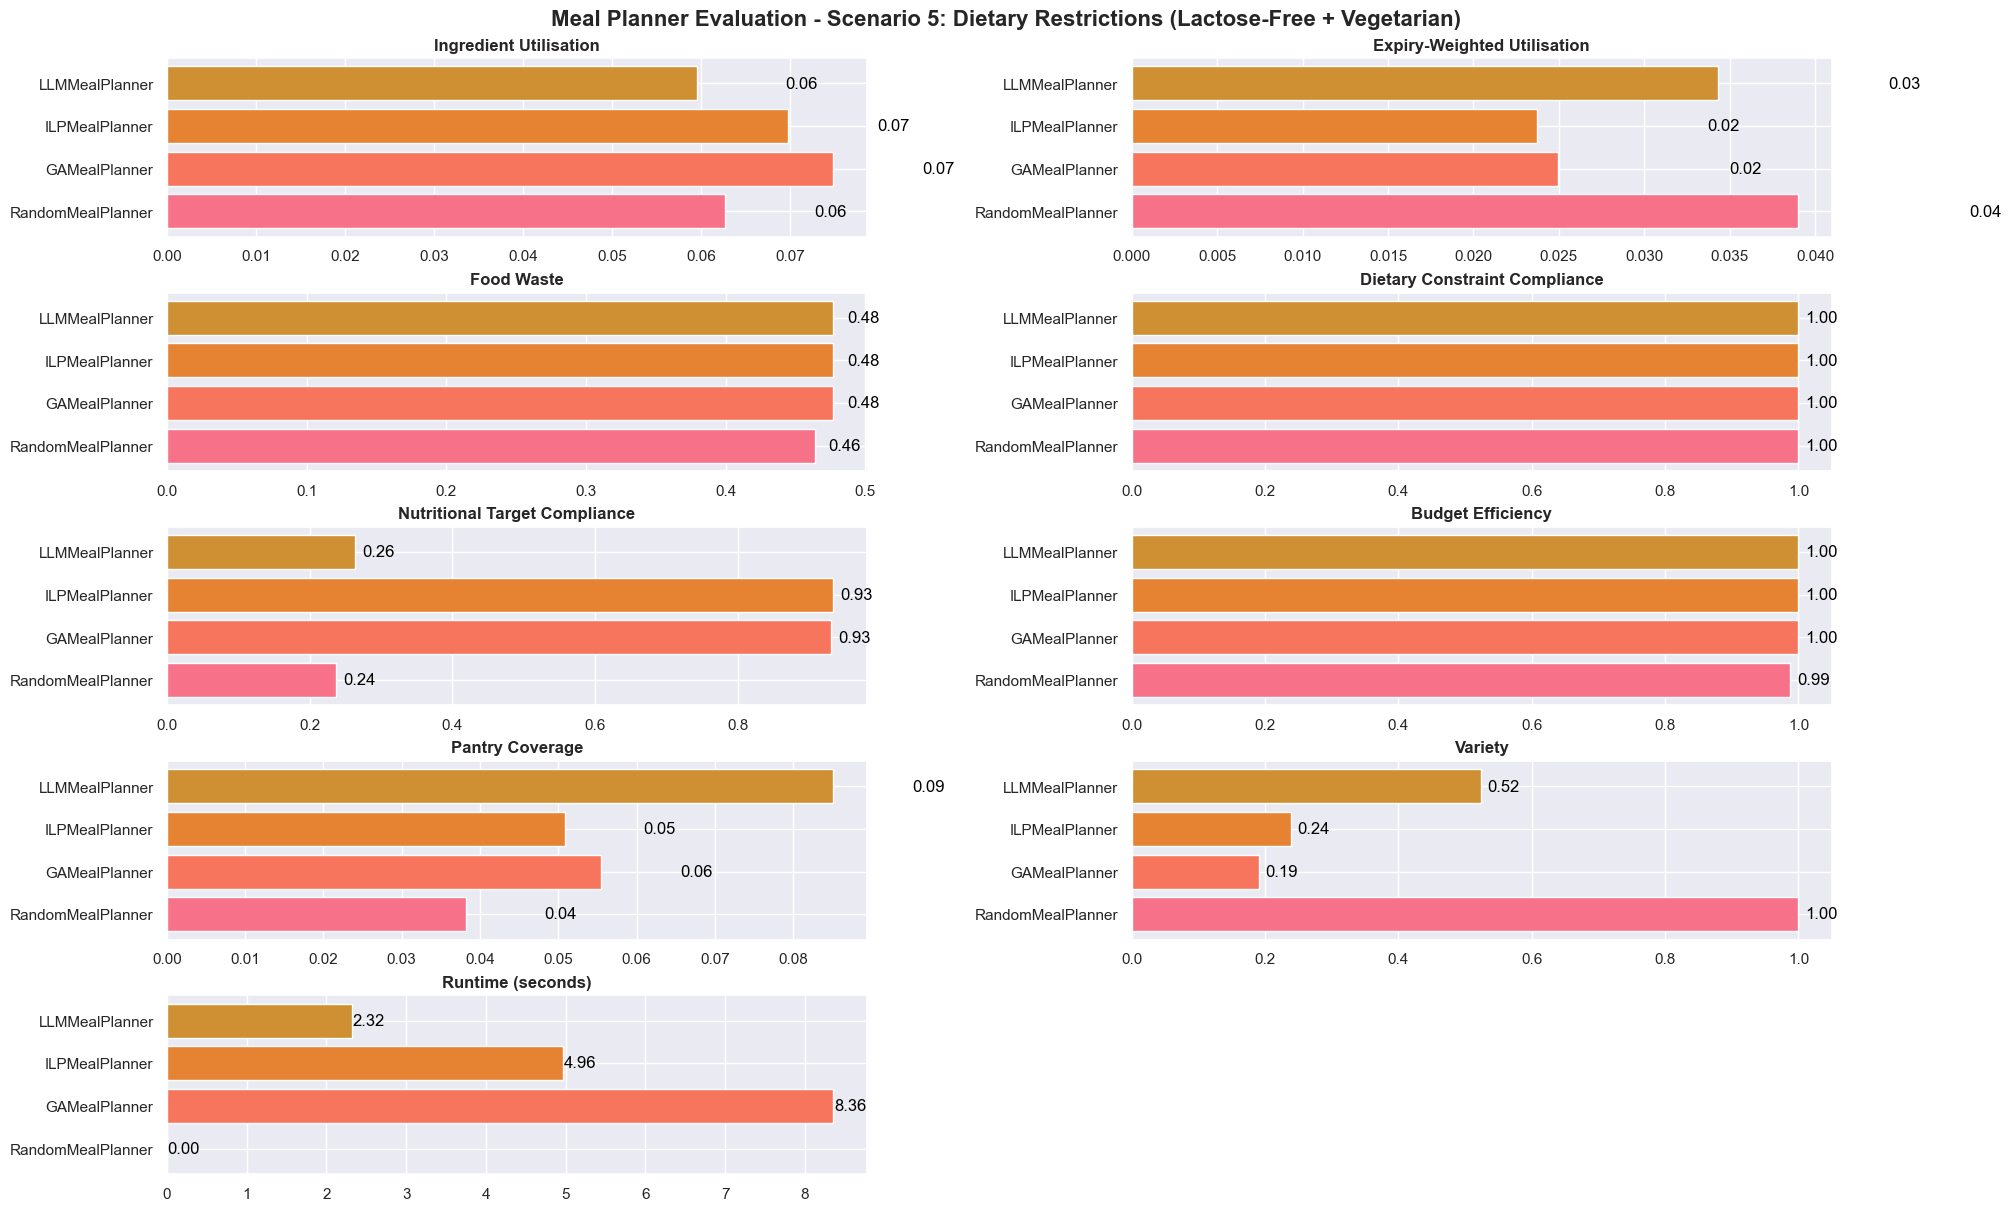

In [22]:
plot_metrics(scenario_5_metrics, f"Meal Planner Evaluation - {scenario_names[4]}", filename = "scenario_5_metrics")

In [23]:
print(
    f"Fitness scores for GA and ILP Meal Planners in {scenario_names[4]} = {best_fitness_scores[('GAMealPlanner', 5)]:.4} (GA), {best_fitness_scores[('ILPMealPlanner', 5)]:.4} (ILP)"
)

Fitness scores for GA and ILP Meal Planners in Scenario 5: Dietary Restrictions (Lactose-Free + Vegetarian) = -0.2987 (GA), -0.3002 (ILP)


### *Scenario 6*

In [24]:
scenario_6_metrics = {planner: metrics for (planner, scenario), metrics in planner_metrics.items() if scenario == 6}

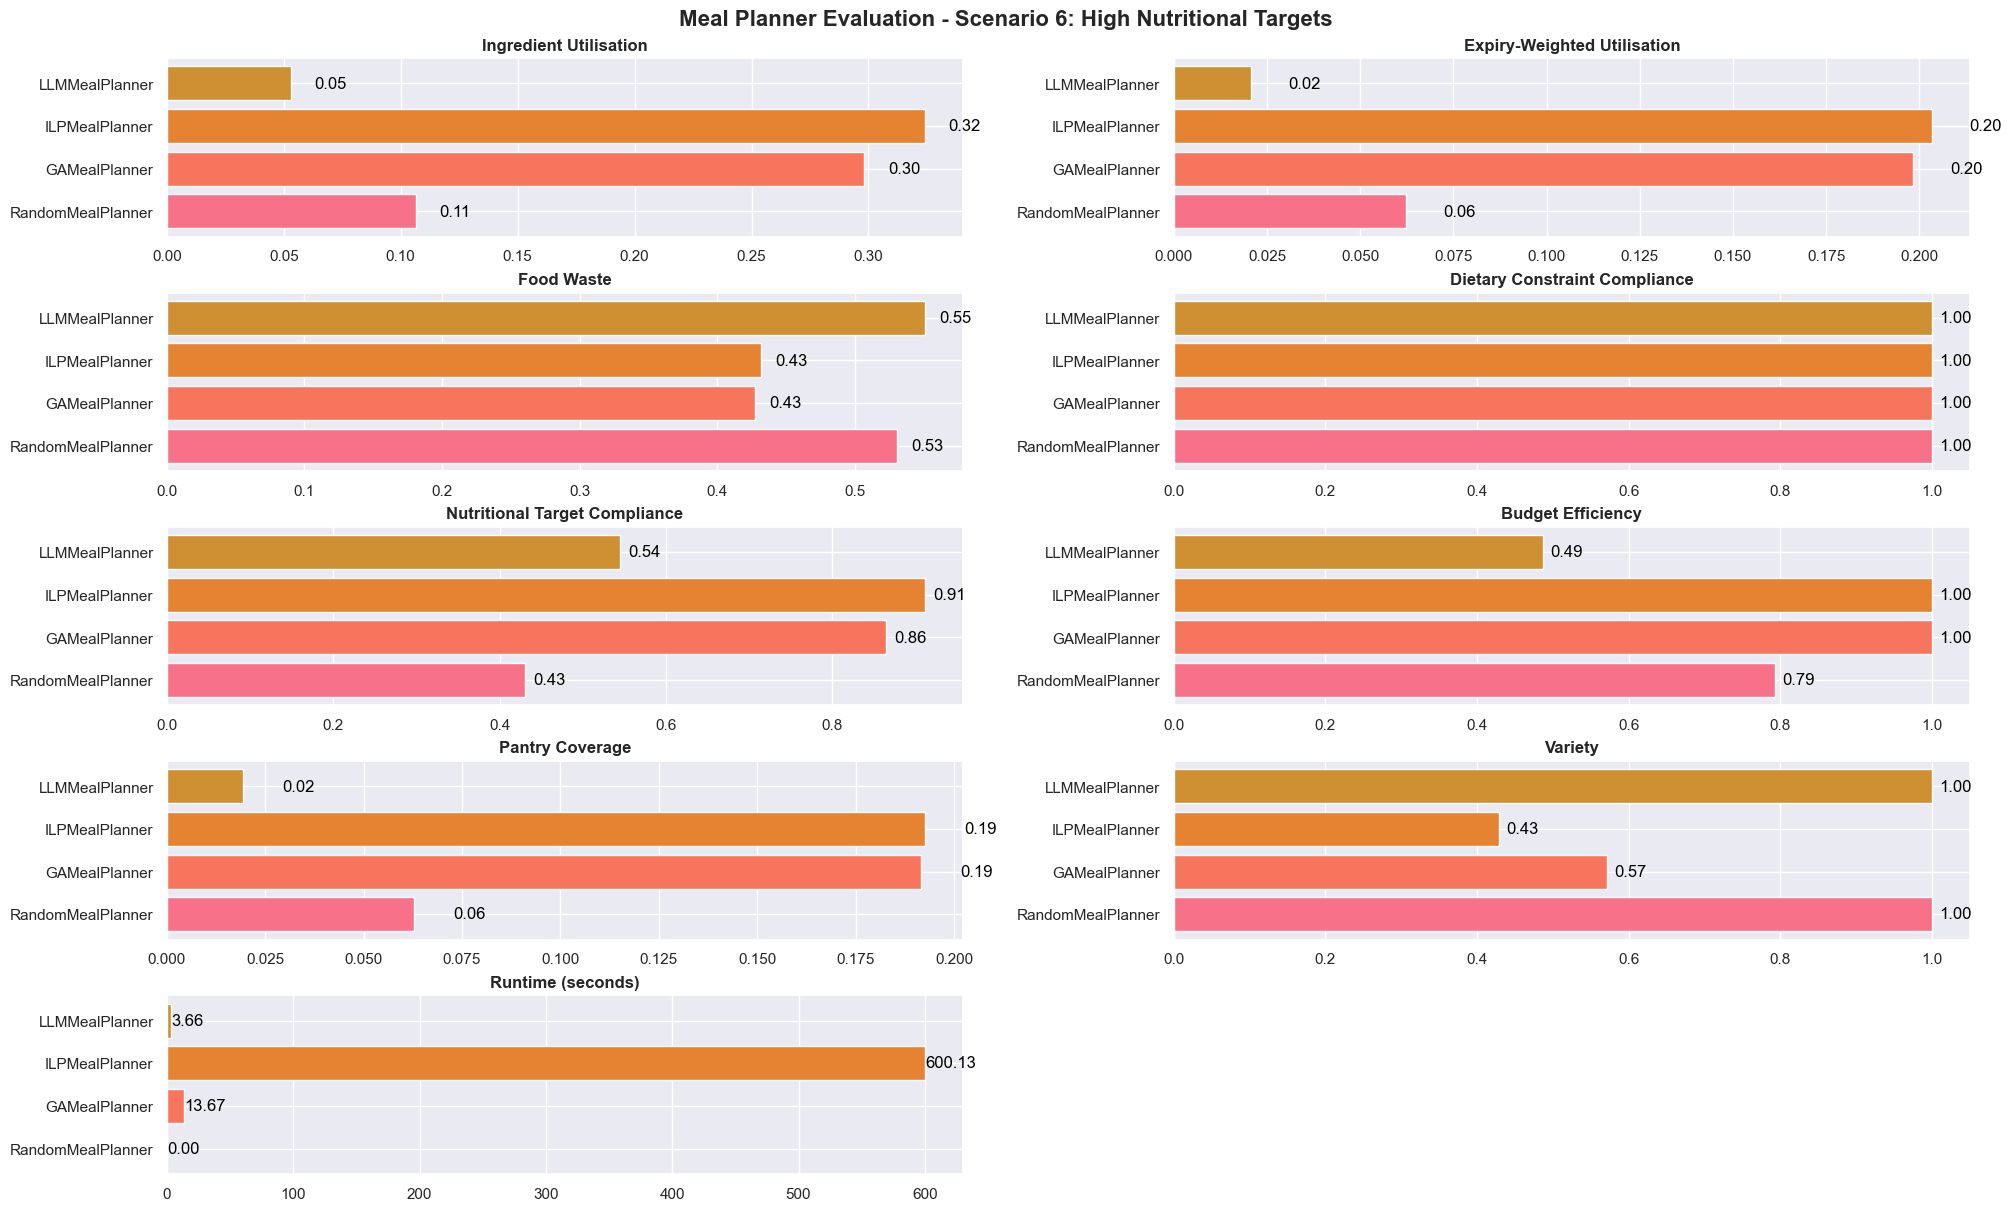

In [25]:
plot_metrics(scenario_6_metrics, f"Meal Planner Evaluation - {scenario_names[5]}", filename = "scenario_6_metrics")

In [26]:
print(
    f"Fitness scores for GA and ILP Meal Planners in {scenario_names[5]} = {best_fitness_scores[('GAMealPlanner', 6)]:.4} (GA), {best_fitness_scores[('ILPMealPlanner', 6)]:.4} (ILP)"
)

Fitness scores for GA and ILP Meal Planners in Scenario 6: High Nutritional Targets = -0.2636 (GA), -0.218 (ILP)


## Average across Scenarios

In [ ]:
def plot_average_metrics(planner_metrics: dict[str, float], title: str, filename: str) -> None:
    """
    Plots the average metric values across all scenarios for each meal planner as horizontal bar charts with error bars representing the standard deviation

    :param planner_metrics: mapping of metric names to their average values and standard deviations across all scenarios
    :type planner_metrics: dict[str, float]
    :param title: the title for the overall plot
    :type title: str
    :param filename: the filename to save the plot as (without extension)
    :type filename: str
    """
    
    fig, axes = plt.subplots(5, 2, figsize=(20, 12), constrained_layout=True)

    for i, (ax, (metric_key, metric_title)) in enumerate(zip(axes.flat, metrics_to_plot)):
        std_key = metric_key[:-5] + "_std"
        mean = planner_metrics.get(metric_key, 0)
        std = planner_metrics.get(std_key, 0)

        ax.barh(0, mean, xerr=std, color=colours[i], error_kw={"capsize": 5})

        ax.set_yticks([0])
        ax.set_yticklabels([""])
        ax.set_title(metric_title, fontweight="bold")

        x_min, x_max = ax.get_xlim()
        ax.set_xlim(x_min, x_max)

        if std == 0:
            continue

        lo, hi = mean - std, mean + std

        ax.text(hi, 0, f" {hi:.4f}", va="center", ha="left", fontsize=12, clip_on=False)

        ax.text(lo, 0, f"{lo:.4f} ", va="center", ha="right", fontsize=12, clip_on=False)

    for j in range(len(metrics_to_plot), len(axes.flat)):
        axes.flat[j].axis("off")

    fig.suptitle(title, fontsize=16, fontweight="bold")
    plt.savefig(f"./figures/{filename}.png", dpi = 900)
    plt.show()

#### *Random Meal Planner*

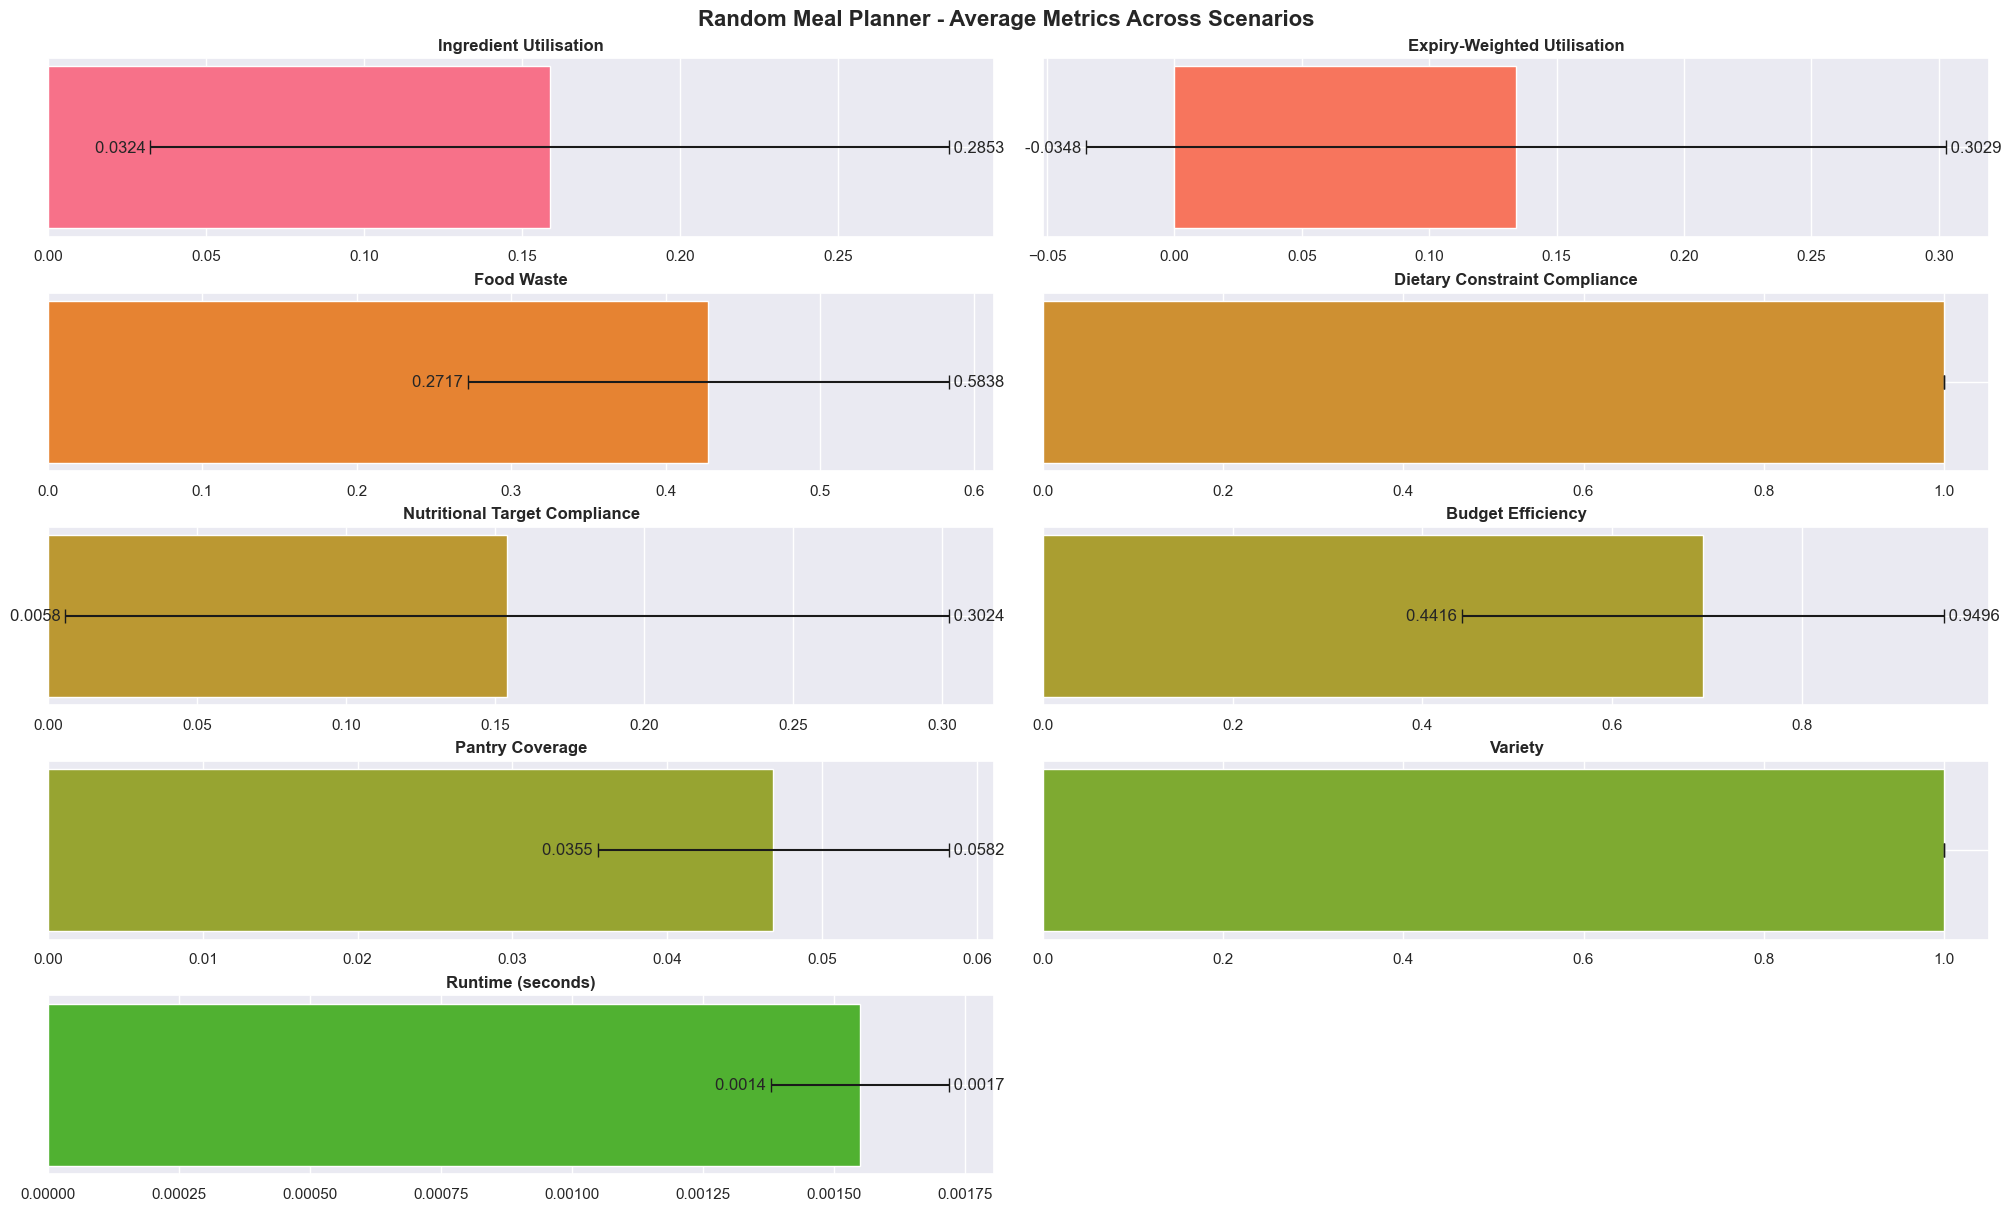

In [28]:
plot_average_metrics(average_metrics["RandomMealPlanner"], "Random Meal Planner - Average Metrics Across Scenarios", filename= "random_meal_planner_average_metrics")

#### *GA Meal Planner*

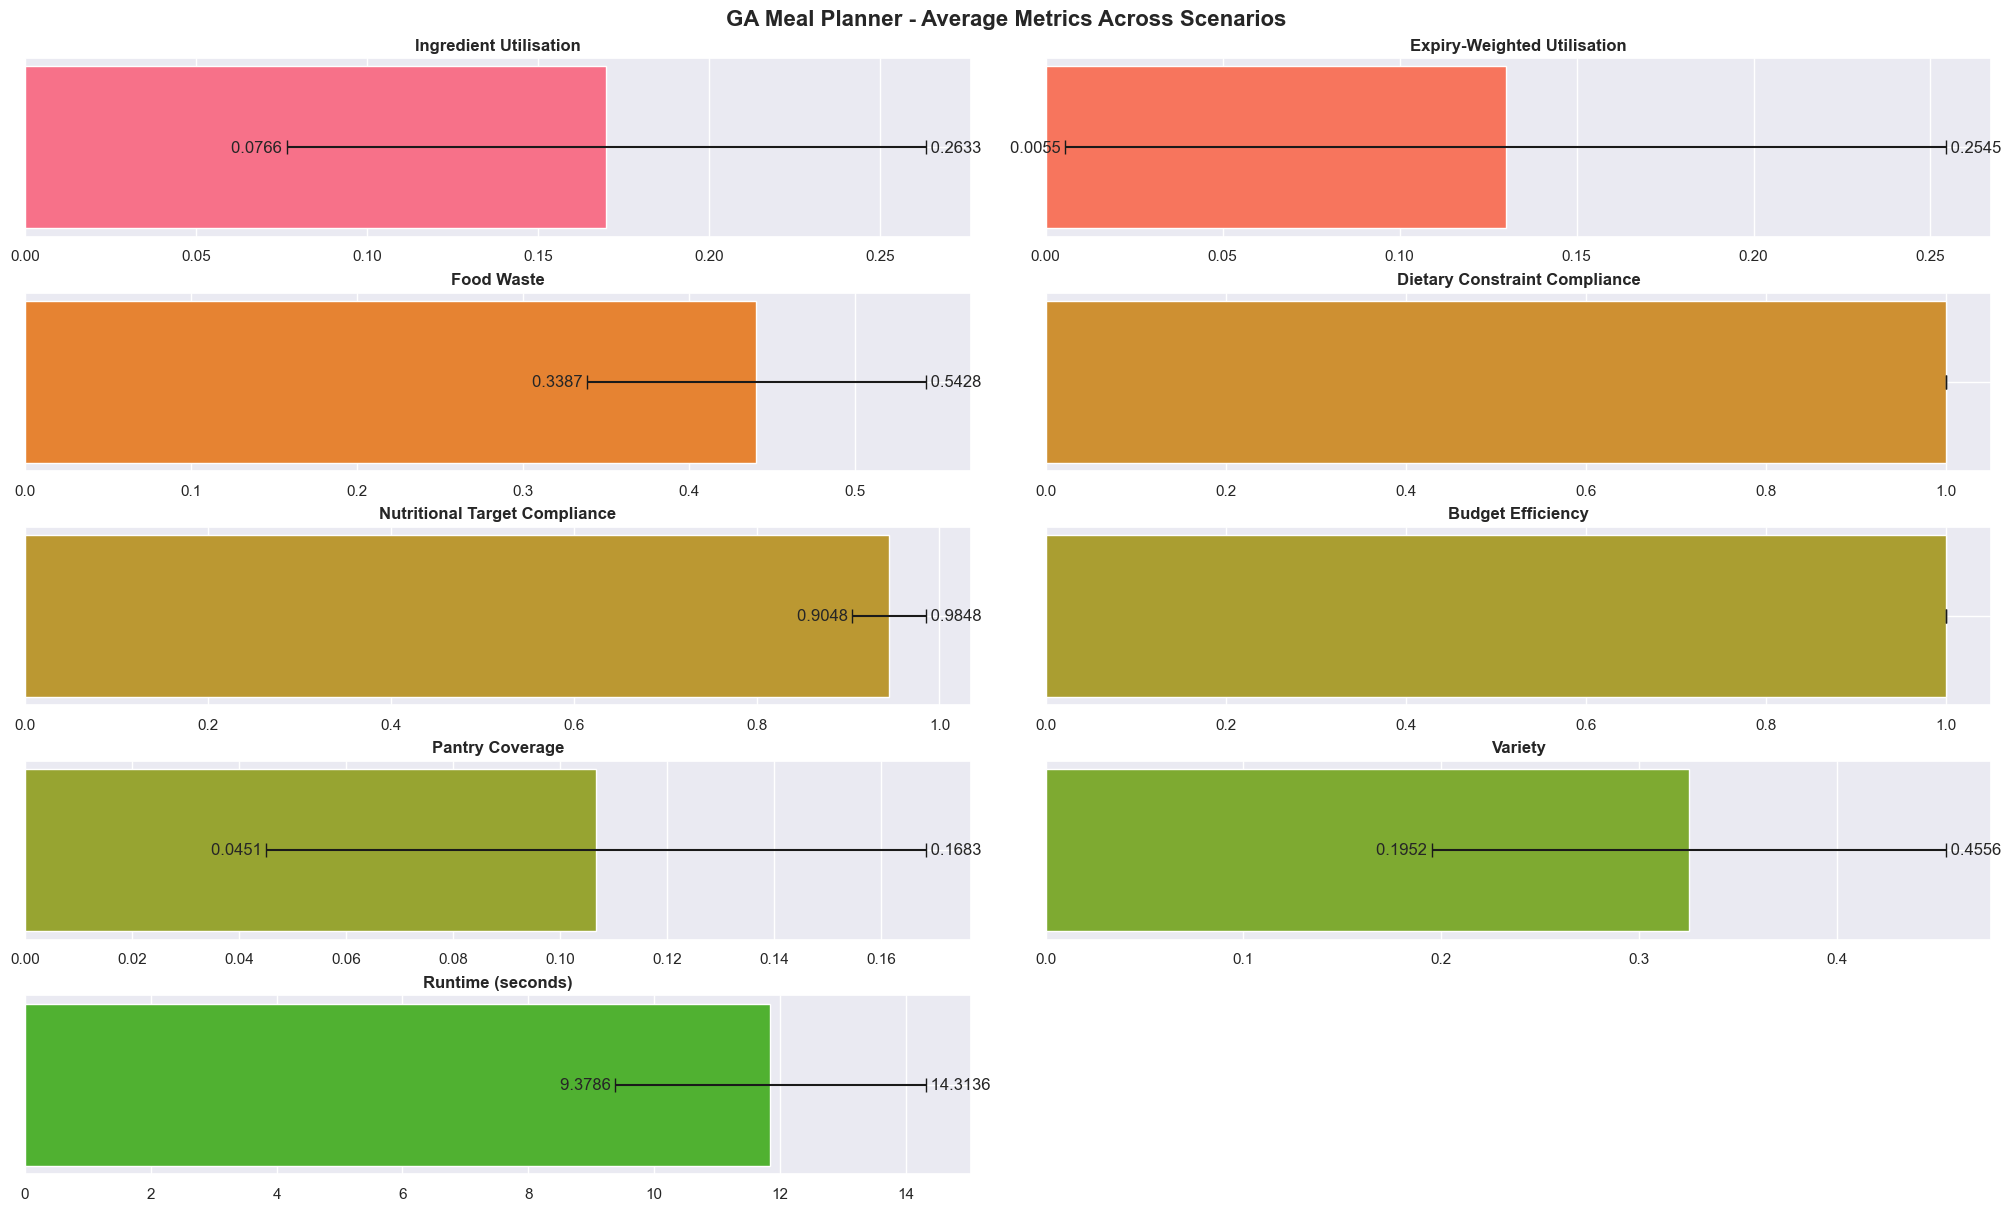

In [29]:
plot_average_metrics(average_metrics["GAMealPlanner"], "GA Meal Planner - Average Metrics Across Scenarios", filename= "ga_meal_planner_average_metrics")

#### *ILP Meal Planner*

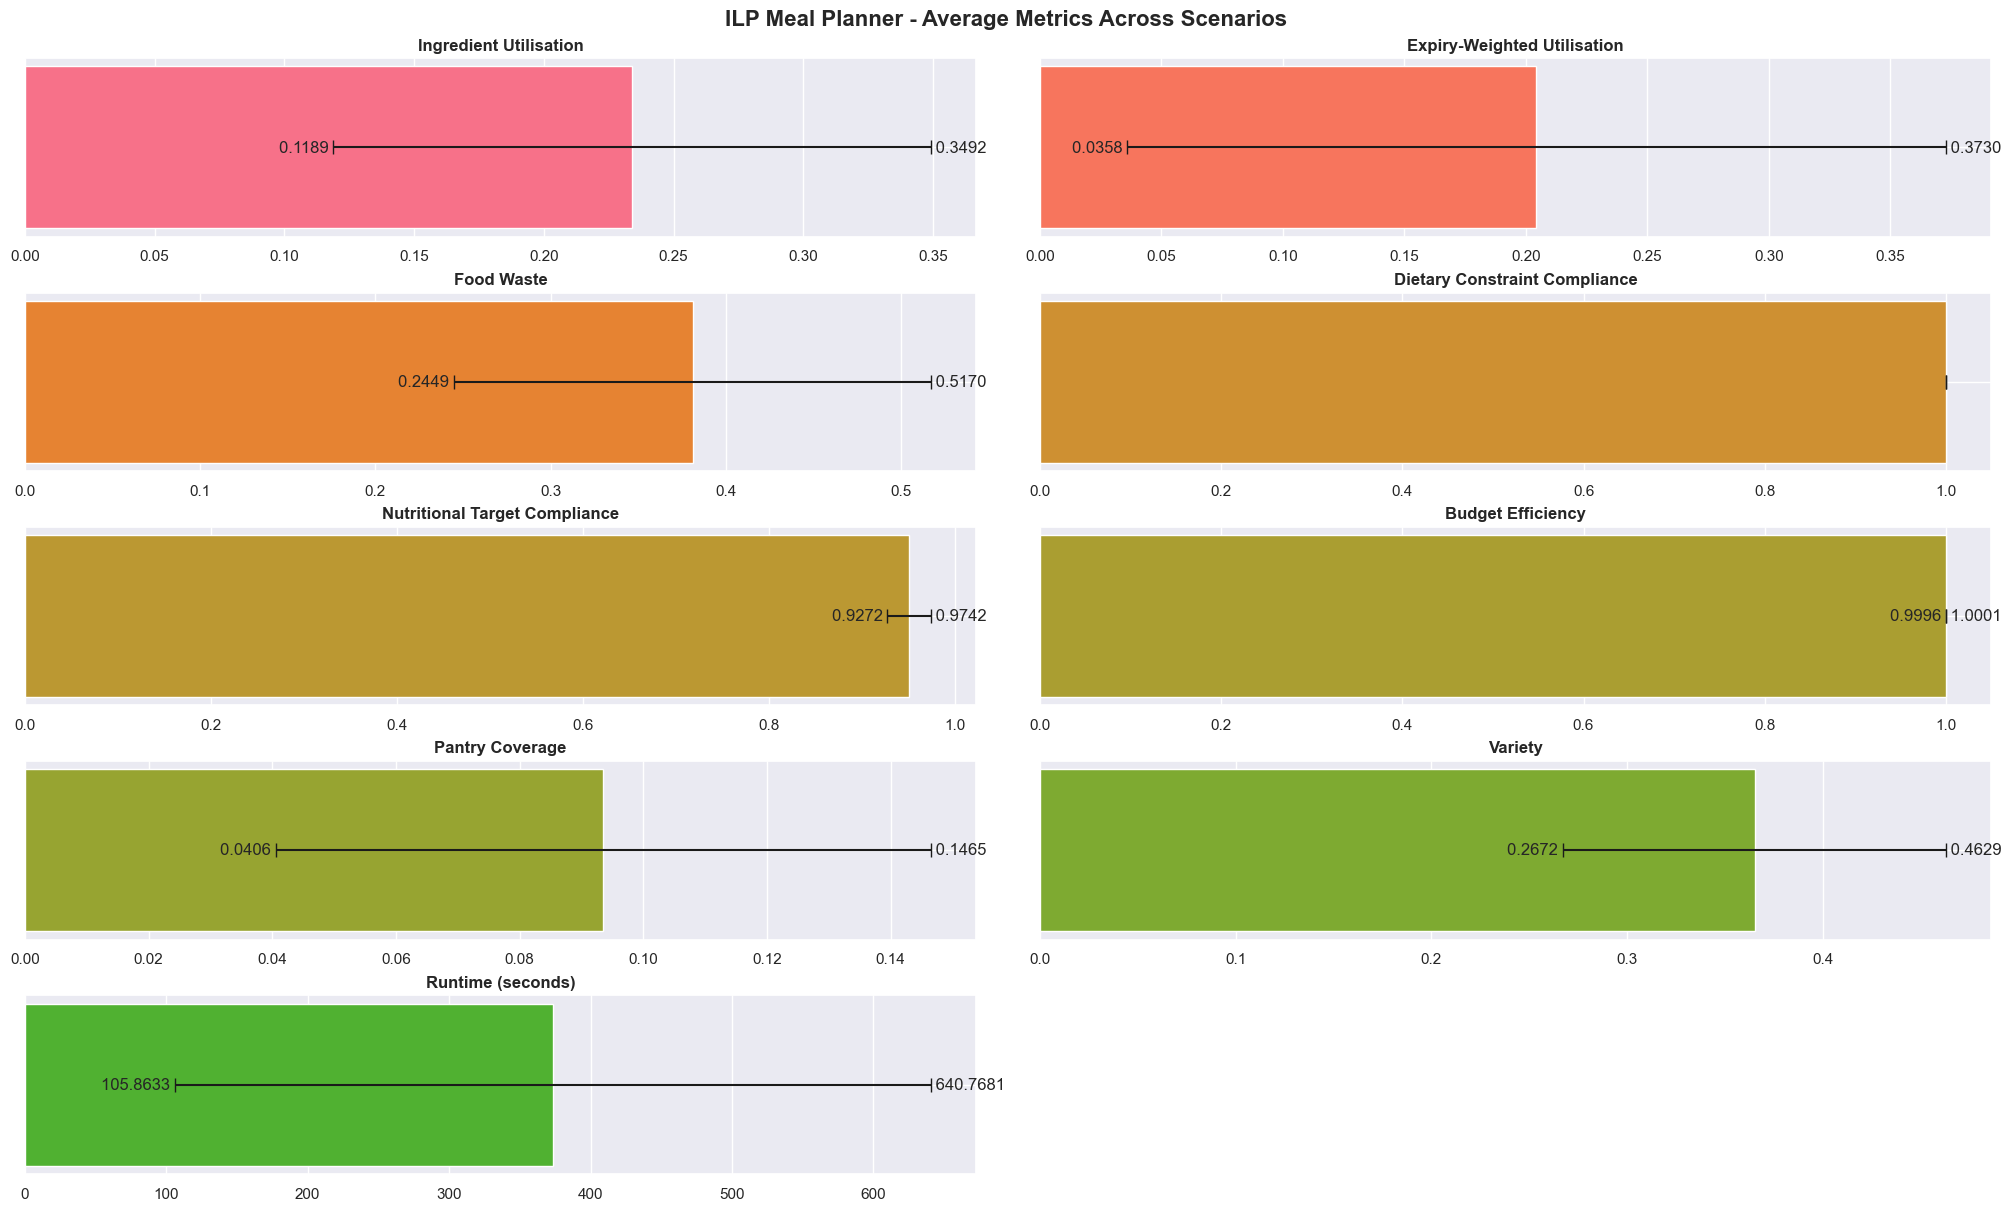

In [30]:
plot_average_metrics(average_metrics["ILPMealPlanner"], "ILP Meal Planner - Average Metrics Across Scenarios", filename= "ilp_meal_planner_average_metrics")

#### *LLM Meal Planner*

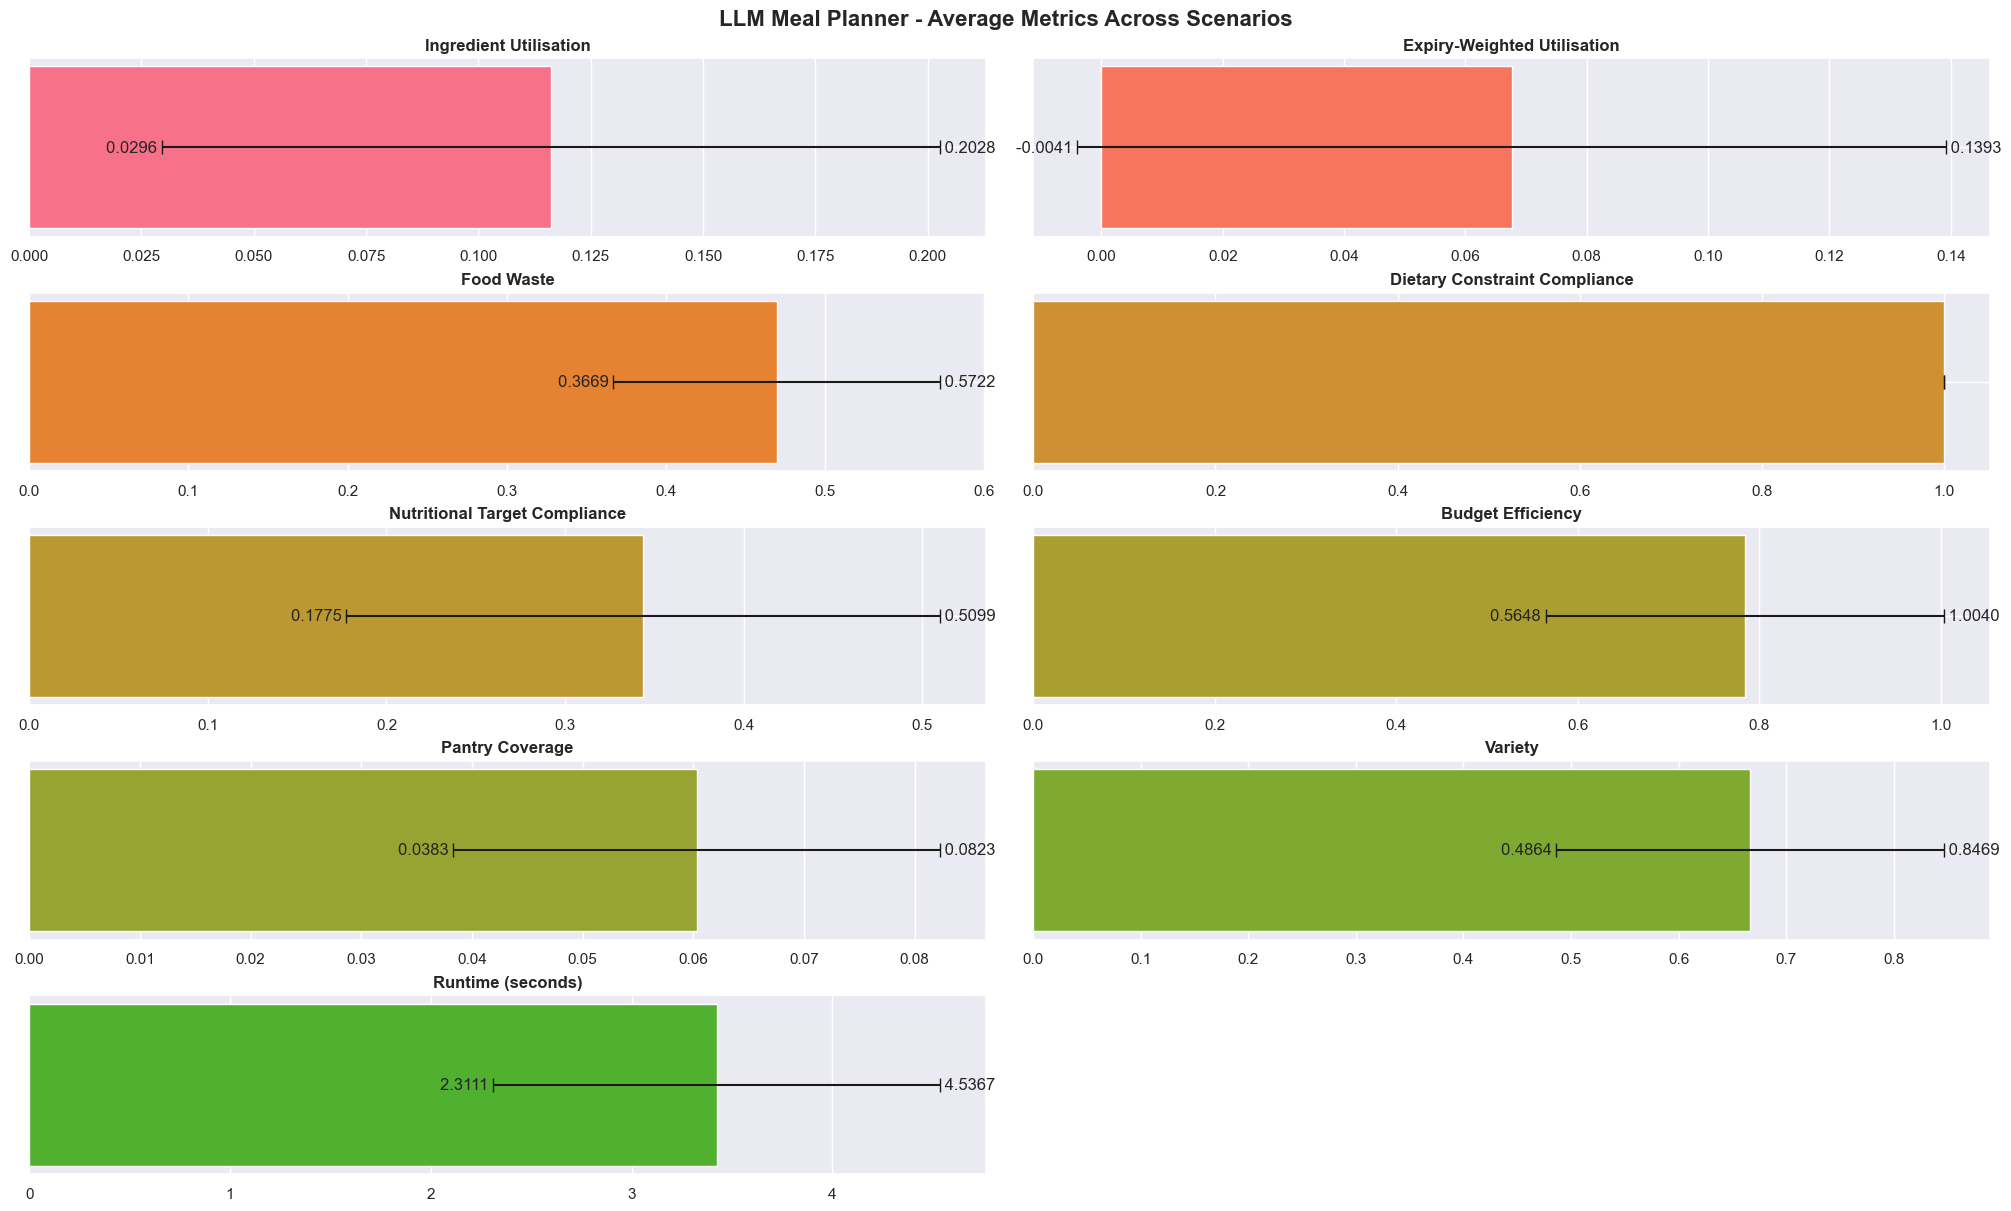

In [31]:
plot_average_metrics(average_metrics["LLMMealPlanner"], "LLM Meal Planner - Average Metrics Across Scenarios", filename= "llm_meal_planner_average_metrics")

### GA vs ILP Comparison

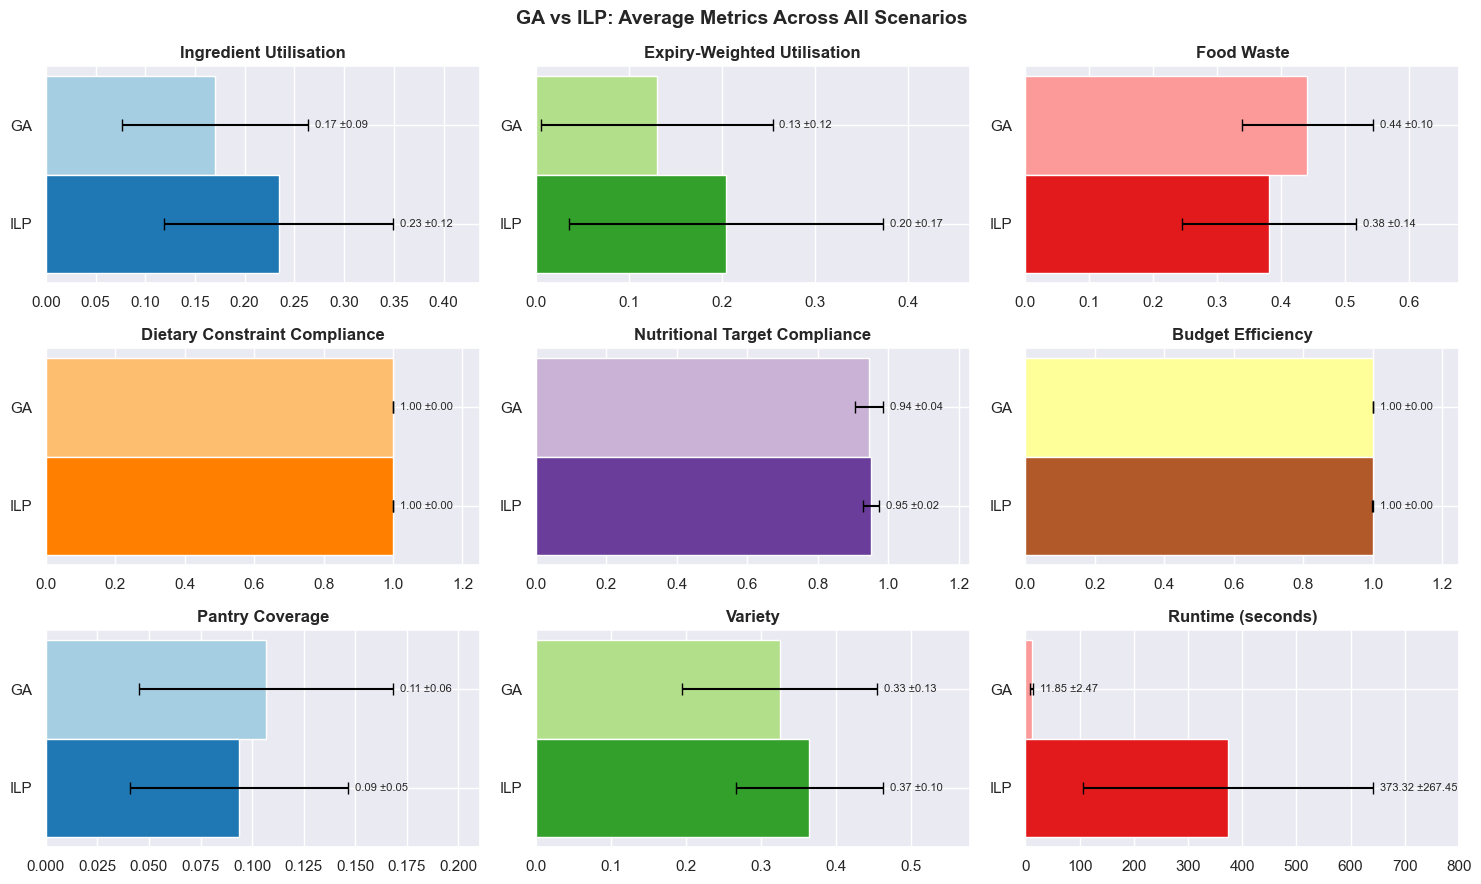

In [32]:
ga_metrics = average_metrics["GAMealPlanner"]
ilp_metrics = average_metrics["ILPMealPlanner"]

metric_labels = [label for _, label in metrics_to_plot]
metric_keys = [key for key, _ in metrics_to_plot]

n_metrics = len(metric_keys)
n_cols = 3
n_rows = (n_metrics + n_cols - 1) // n_cols

ga_ilp_palette = sns.color_palette("Paired", n_metrics * 2)
ga_colours = [ga_ilp_palette[i * 2] for i in range(n_metrics)]
ilp_colours = [ga_ilp_palette[i * 2 + 1] for i in range(n_metrics)]

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3))

height = 0.35

for i, (metric_key, metric_label) in enumerate(zip(metric_keys, metric_labels)):
    ax = axes.flat[i]

    std_key = metric_key[:-5] + "_std"

    ga_val = ga_metrics[metric_key]
    ilp_val = ilp_metrics[metric_key]
    ga_std = ga_metrics.get(std_key, 0)
    ilp_std = ilp_metrics.get(std_key, 0)

    ax.barh(
        height / 2,
        ga_val,
        height,
        label="GA",
        color=ga_colours[i],
        xerr=ga_std,
        error_kw={"capsize": 4, "elinewidth": 1.5, "ecolor": "black"},
    )
    ax.barh(
        -height / 2,
        ilp_val,
        height,
        label="ILP",
        color=ilp_colours[i],
        xerr=ilp_std,
        error_kw={"capsize": 4, "elinewidth": 1.5, "ecolor": "black"},
    )

    max_val = max(ga_val + ga_std, ilp_val + ilp_std)
    offset = max_val * 0.02

    ax.text(ga_val + ga_std + offset, height / 2, f"{ga_val:.2f} ±{ga_std:.2f}", va="center", fontsize=8)
    ax.text(ilp_val + ilp_std + offset, -height / 2, f"{ilp_val:.2f} ±{ilp_std:.2f}", va="center", fontsize=8)

    ax.set_xlim(0, max_val * 1.25)
    ax.set_yticks([height / 2, -height / 2])
    ax.set_yticklabels(["GA", "ILP"])
    ax.set_title(metric_label, fontweight="bold")

# hide any unused subplots
for j in range(n_metrics, n_rows * n_cols):
    axes.flat[j].set_visible(False)

fig.suptitle("GA vs ILP: Average Metrics Across All Scenarios", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("./figures/ga_vs_ilp_average_metrics.png", dpi=900)
plt.show()

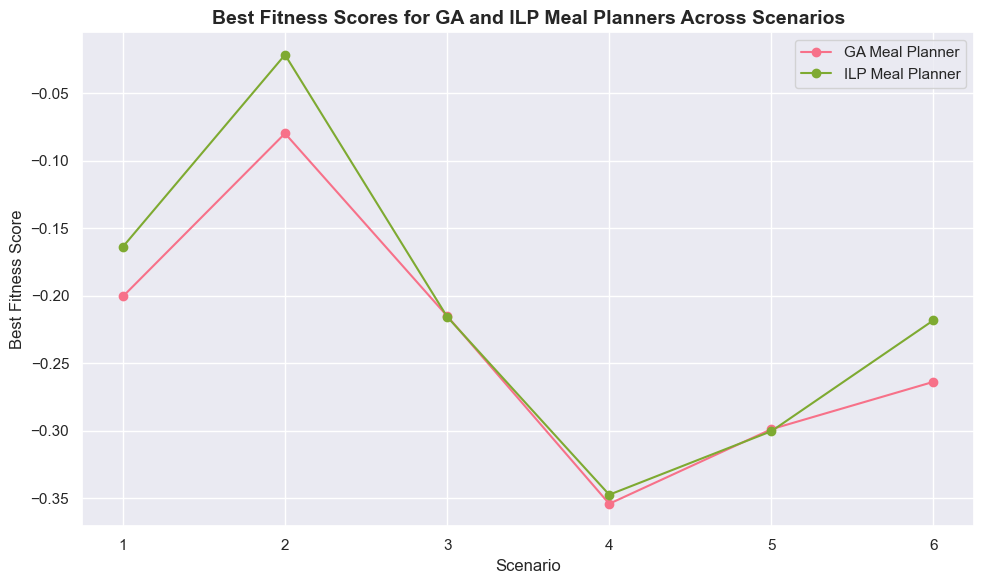

In [33]:
ga_fitness_scores = [best_fitness_scores[("GAMealPlanner", scenario)] for scenario in range(1, 7)]
ilp_fitness_scores = [best_fitness_scores[("ILPMealPlanner", scenario)] for scenario in range(1, 7)]

plt.figure(figsize=(10, 6))

plt.plot(range(1, 7), ga_fitness_scores, marker="o", label="GA Meal Planner", color=colours[0])
plt.plot(range(1, 7), ilp_fitness_scores, marker="o", label="ILP Meal Planner", color=colours[7])

plt.xlabel("Scenario")
plt.ylabel("Best Fitness Score")

plt.title("Best Fitness Scores for GA and ILP Meal Planners Across Scenarios", fontweight="bold", fontsize = 14)

plt.legend()
plt.tight_layout()
plt.savefig("./figures/ga_vs_ilp_fitness_scores.png", dpi=900)
plt.show()